# PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng
đầu tiên.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(path):
    df = pd.read_csv(path)
    return df

# Load dữ liệu
df = load_data("/content/titanic_disaster.csv")

# Hiển thị 10 dòng đầu
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat
map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked


In [ ]:
# Kiểm tra số lượng giá trị thiếu
missing_data = df.isnull().sum()
# Tính phần trăm thiếu
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing_data,
    "Missing Percent (%)": missing_percent
})
missing_summary

,Missing Count,Missing Percent (%)
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


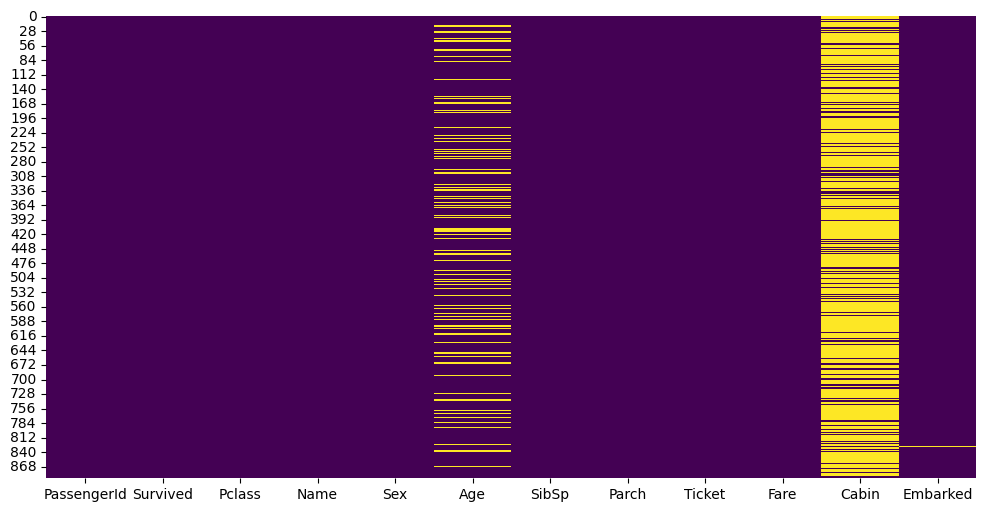

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.show()

3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi
tách cột xong thì xóa luôn cột Name

In [ ]:
# Tách theo dấu phẩy trước và kiểm tra nếu cột 'Name' tồn tại
if 'Name' in df.columns:
    df[['secondName', 'firstName']] = df['Name'].str.split(',', expand=True)

    # Xóa cột Name
    df.drop(columns=['Name'], inplace=True)

# Kiểm tra kết quả
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,secondName,firstName
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry


4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F

In [ ]:
df['Sex'] = df['Sex'].map({
    'male': 'M',
    'female': 'F'
})
df['Sex'].head()

,Sex
0,M
1,F
2,F
3,F
4,M


5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau

a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.

b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map.

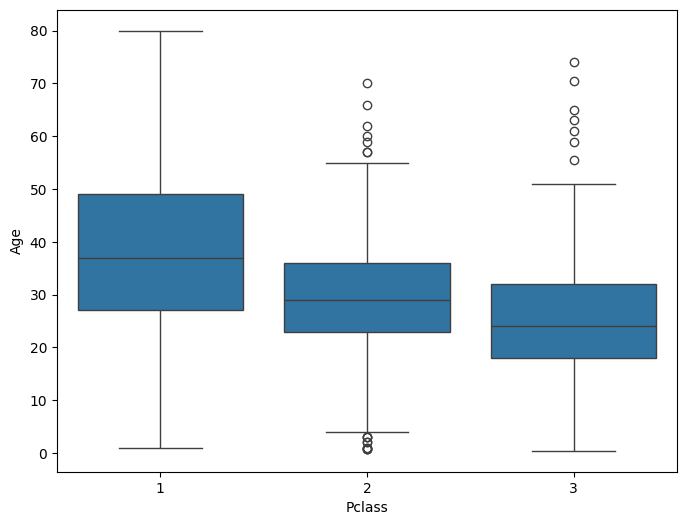

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.show()

In [ ]:
mean_age_by_class = df.groupby('Pclass')['Age'].mean()
mean_age_by_class
df['Age'] = df.groupby('Pclass')['Age']\
              .transform(lambda x: x.fillna(x.mean()))
df['Age'].isnull().sum()

np.int64(0)

6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa
trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult và ( age > 60): Older

In [ ]:
def age_group(age):
    if age <= 12:
        return "Kid"
    elif age <= 18:
        return "Teen"
    elif age <= 60:
        return "Adult"
    else:
        return "Older"

df['Agegroup'] = df['Age'].apply(age_group)
df[['Age', 'Agegroup']].head()

,Age,Agegroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách Mr,
Mrs, Miss, Master ra khỏi “secondName”


In [ ]:
df['namePrefix'] = df['firstName'].str.split('.').str[0]
df['namePrefix'].value_counts()

,count
namePrefix,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối
với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch

In [ ]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'familySize']].head()

,SibSp,Parch,familySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


  9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách
dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0.

In [ ]:
df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)
df[['familySize', 'Alone']].head()

,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính
cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu
thì thay thế bằng “Unknown”

In [ ]:
df['Cabin'] = df['Cabin'].fillna("Unknown")
df['typeCabin'] = df['Cabin'].str[0]
df[['Cabin', 'typeCabin']].head()

,Cabin,typeCabin
0,Unknown,U
1,C85,C
2,Unknown,U
3,C123,C
4,Unknown,U


# PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA


12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính.


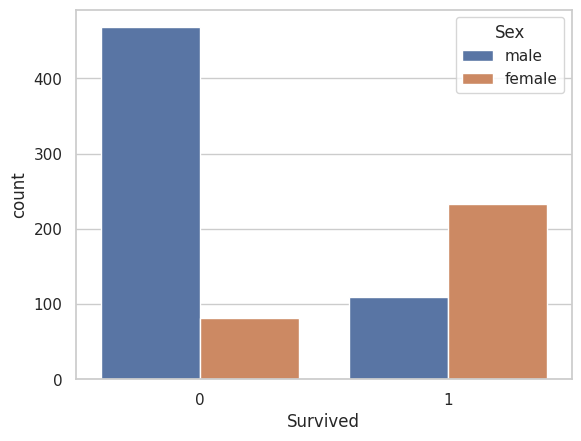

In [66]:
sns.countplot(x='Survived', hue='Sex', data= df)
plt.show()

13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass).

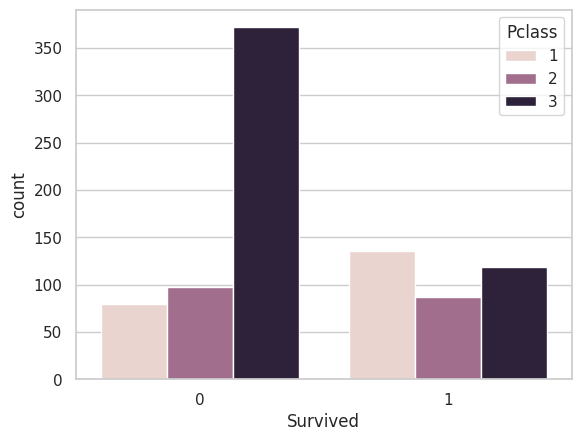

In [68]:
sns.countplot(x='Survived', hue='Pclass', data= df)
plt.show()

14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác


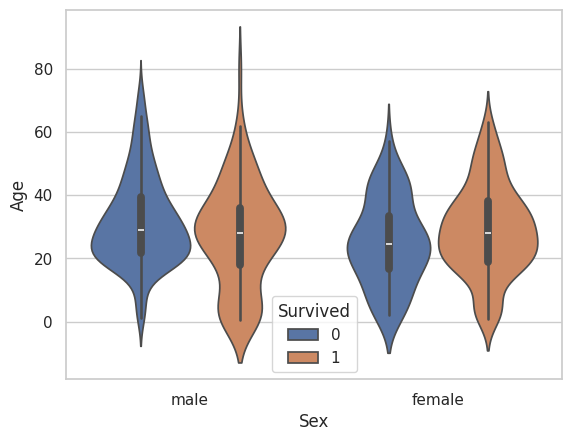

In [70]:
sns.violinplot(x='Sex', y = 'Age',  hue='Survived', data= df)
plt.show()

15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng


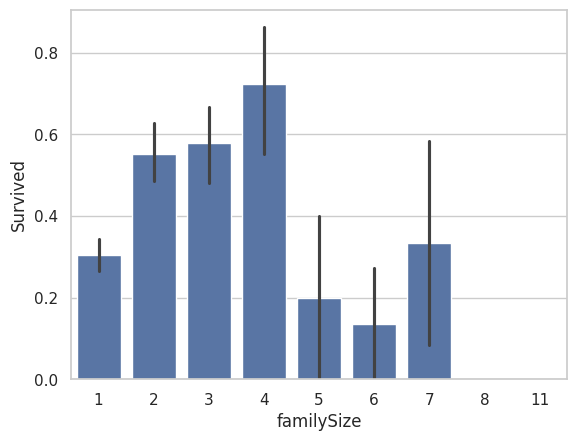

In [75]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']
df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)
sns.barplot(x='familySize', y='Survived', data=df)
plt.show()

16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé

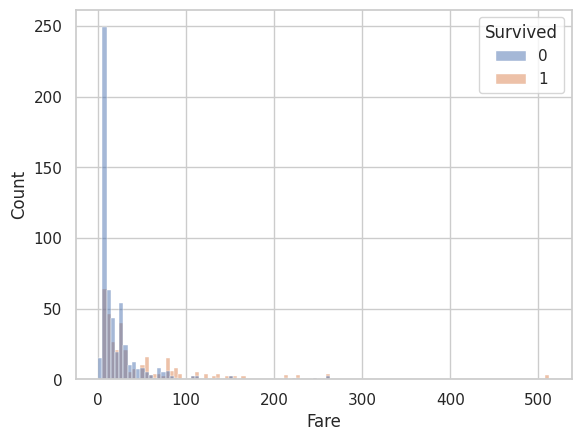

In [78]:
sns.histplot(x='Fare', hue='Survived', data=df)
plt.show()

17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và
cảng sẽ cập bến.

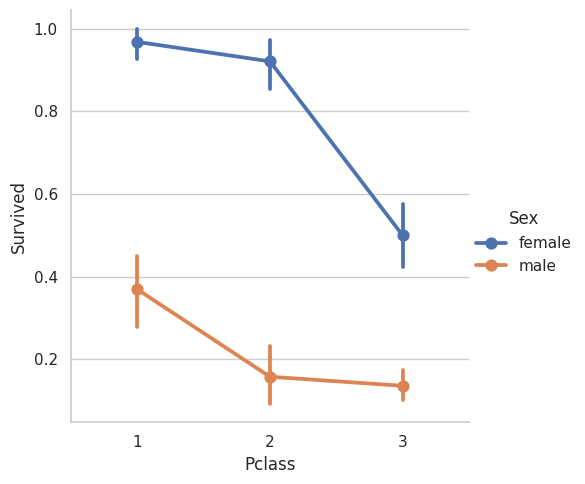

In [80]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind= 'point', data= df)
plt.show()